In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dishaaagrawal12/master-dataset/master_clean_df.csv


In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [6]:
df = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/master-dataset/master_clean_df.csv')

In [7]:
# M&M stored as MM

SECTOR = {
    "ADANIPORTS": "Infrastructure",
    "ASIANPAINT": "Consumer Goods",
    "AXISBANK": "Banking",
    "BAJAJ-AUTO": "Automobile",
    "BAJAJFINSV": "Financial Svcs",
    "BAJFINANCE": "Financial Svcs",
    "BHARTIARTL": "Telecom",
    "BPCL": "Energy",
    "BRITANNIA": "Consumer Goods",
    "CIPLA": "Pharma",
    "COALINDIA": "Energy",
    "DRREDDY": "Pharma",
    "EICHERMOT": "Automobile",
    "GAIL": "Energy",
    "GRASIM": "Materials",
    "HCLTECH": "IT",
    "HDFC": "Financial Svcs",
    "HDFCBANK": "Banking",
    "HEROMOTOCO": "Automobile",
    "HINDALCO": "Materials",
    "HINDUNILVR": "Consumer Goods",
    "ICICIBANK": "Banking",
    "INDUSINDBK": "Banking",
    "INFY": "IT",
    "IOC": "Energy",
    "ITC": "Consumer Goods",
    "JSWSTEEL": "Materials",
    "KOTAKBANK": "Banking",
    "LT": "Infrastructure",
    "MM": "Automobile",
    "MARUTI": "Automobile",
    "NESTLEIND": "Consumer Goods",
    "NTPC": "Energy",
    "ONGC": "Energy",
    "POWERGRID": "Energy",
    "RELIANCE": "Energy",
    "SBIN": "Banking",
    "SHREECEM": "Materials",
    "SUNPHARMA": "Pharma",
    "TATAMOTORS": "Automobile",
    "TATASTEEL": "Materials",
    "TCS": "IT",
    "TECHM": "IT",
    "TITAN": "Consumer Goods",
    "ULTRACEMCO": "Materials",
    "UPL": "Chemicals",
    "VEDL": "Materials",
    "WIPRO": "IT",
    "ZEEL": "Media"
}

df["Sector"] = (
    df["Symbol"]
    .map(SECTOR)
    .fillna("Other")
)

"Sector distribution (unique stocks):"
df.groupby("Sector")["Symbol"].nunique().sort_values(ascending=False)

Sector
Energy            8
Materials         7
Automobile        6
Consumer Goods    6
Banking           6
IT                5
Financial Svcs    3
Pharma            3
Infrastructure    2
Chemicals         1
Media             1
Other             1
Telecom           1
Name: Symbol, dtype: int64

In [8]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble', 'NIFTY_Open', 'NIFTY_High', 'NIFTY_Low', 'NIFTY_Close',
       'NIFTY_Volume', 'NIFTY_Turnover', 'NIFTY_Return', 'NIFTY_MA20',
       'NIFTY_MA50', 'NIFTY_Volatility_20', 'DV_Missing', '%D_Missing',
       'Sector'],
      dtype='object')

In [9]:
rows_per_stock = (
    df.groupby("Symbol")
      .size()
      .sort_values()
)

In [10]:
print("\nStocks with fewest trading days:")
rows_per_stock.head(6)


Stocks with fewest trading days:


Symbol
COALINDIA     2598
BAJAUTOFIN    2611
NESTLEIND     2806
BAJAJFINSV    3201
BAJAJ-AUTO    3202
ADANIPORTS    3322
dtype: int64

In [11]:
print("\nStocks with most trading days:")
rows_per_stock.tail(6)


Stocks with most trading days:


Symbol
SUNPHARMA     5306
TATASTEEL     5306
TATAMOTORS    5306
TITAN         5306
WIPRO         5306
ZEEL          5306
dtype: int64

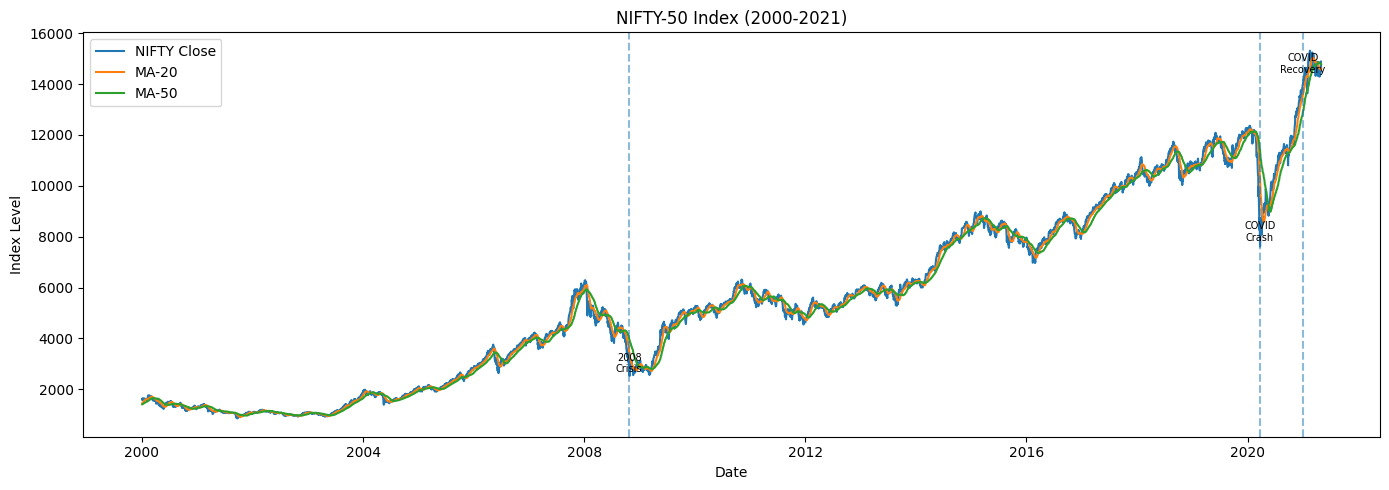

In [12]:
# NIFTY Long-Term Trend

idx = (
    df.drop_duplicates("Date")
      .assign(Date=lambda x: pd.to_datetime(x["Date"]))
      .set_index("Date")
      [["NIFTY_Close", "NIFTY_MA20", "NIFTY_MA50"]]
      .sort_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=idx,
    x=idx.index,
    y="NIFTY_Close",
    label="NIFTY Close"
)

sns.lineplot(
    data=idx,
    x=idx.index,
    y="NIFTY_MA20",
    label="MA-20"
)

sns.lineplot(
    data=idx,
    x=idx.index,
    y="NIFTY_MA50",
    label="MA-50"
)

events = {
    "2008\nCrisis": "2008-10-24",
    "COVID\nCrash": "2020-03-23",
    "COVID\nRecovery": "2021-01-01"
}

for label, date in events.items():

    dt = pd.Timestamp(date)

    if dt in idx.index:

        val = idx.loc[dt, "NIFTY_Close"]

        plt.axvline(
            dt,
            linestyle="--",
            alpha=0.5
        )

        plt.text(
            dt,
            val * 1.03,
            label,
            fontsize=7,
            ha="center"
        )

plt.title("NIFTY-50 Index (2000-2021)")
plt.ylabel("Index Level")

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

plt.tight_layout()
plt.show()

In [13]:
idx.index = pd.to_datetime(idx.index)

In [14]:
print(type(idx.index))
print(idx.index.dtype)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
datetime64[ns]


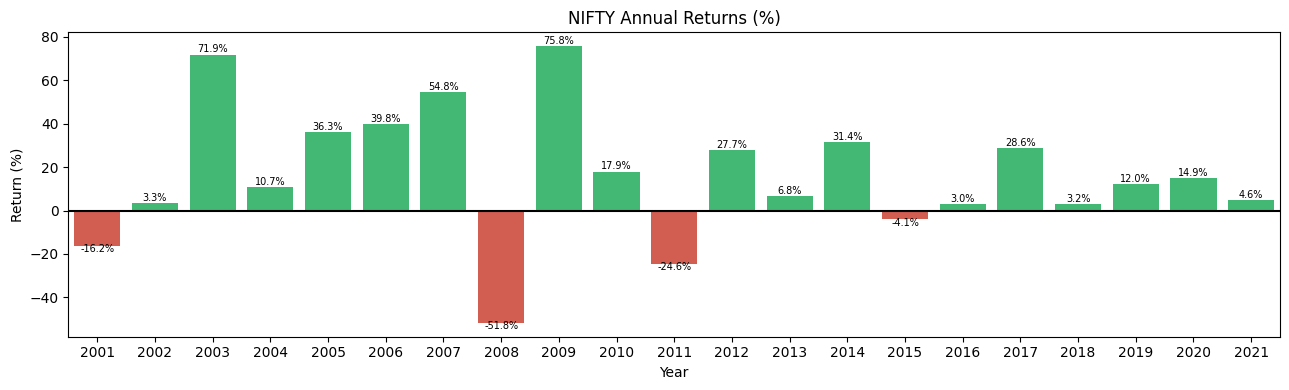

Best year: 2009 → 75.8%
Worst year: 2008 → -51.8%


In [15]:
# Annual Returns

annual_idx = (
    idx["NIFTY_Close"]
    .resample("YE")
    .last()
    .pct_change()
    .dropna()
    .mul(100)
)

annual_idx.index = annual_idx.index.year

annual_df = annual_idx.reset_index()
annual_df.columns = ["Year", "Return"]

colors = [
    "#2ecc71" if x >= 0 else "#e74c3c"
    for x in annual_df["Return"]
]

plt.figure(figsize=(13, 4))

sns.barplot(
    data=annual_df,
    x="Year",
    y="Return",
    hue="Year",
    palette=colors,
    legend=False
)

plt.axhline(0, color="black")

for i, val in enumerate(annual_df["Return"]):

    plt.text(
        i,
        val + (1 if val >= 0 else -3),
        f"{val:.1f}%",
        ha="center",
        fontsize=7
    )

plt.title("NIFTY Annual Returns (%)")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.show()

print(
    "Best year:",
    annual_idx.idxmax(),
    f"→ {annual_idx.max():.1f}%"
)

print(
    "Worst year:",
    annual_idx.idxmin(),
    f"→ {annual_idx.min():.1f}%"
)

/tmp/ipykernel_58/1936402400.py:25: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(
/tmp/ipykernel_58/1936402400.py:33: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(


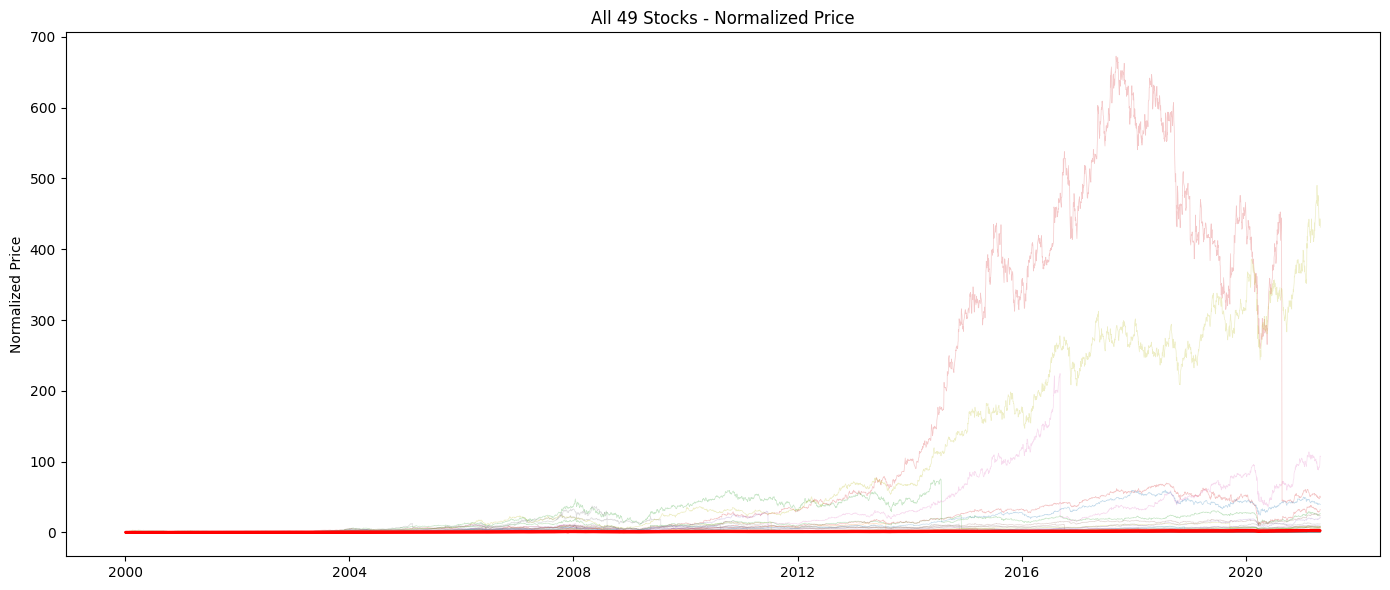

In [16]:
pivot = df.pivot_table(
    index="Date",
    columns="Symbol",
    values="Close"
)

pivot.index = pd.to_datetime(pivot.index)

norm = pivot.div(pivot.bfill().iloc[0])

idx_temp = (
    df.drop_duplicates("Date")
      .copy()
)

idx_temp["Date"] = pd.to_datetime(idx_temp["Date"])
idx_temp = idx_temp.set_index("Date")

idx_norm = idx_temp["NIFTY_Close"] / idx_temp["NIFTY_Close"].iloc[0]

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111)

for col in norm.columns:
    ax.plot_date(
        norm.index,
        norm[col],
        fmt="-",
        alpha=0.25,
        linewidth=0.5
    )

ax.plot_date(
    idx_norm.index,
    idx_norm.values,
    fmt="-",
    linewidth=2,
    color="red"
)

plt.title("All 49 Stocks - Normalized Price")
plt.ylabel("Normalized Price")
plt.tight_layout()
plt.show()

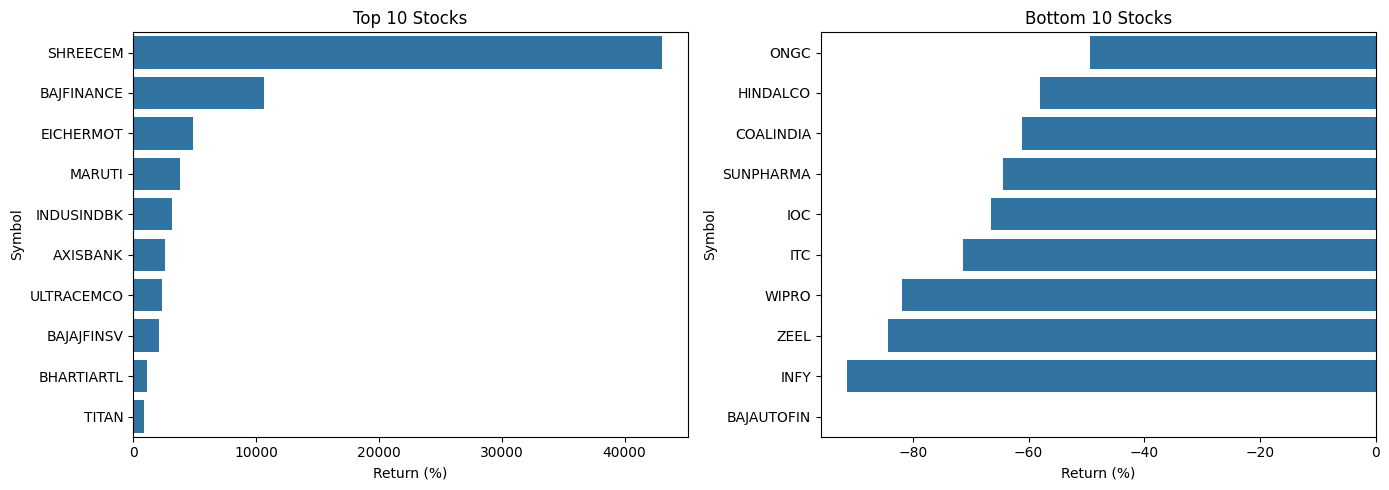

In [17]:
# Top & Bottom Performers

cum_ret = (
    (norm.iloc[-1] - 1)
    .sort_values(ascending=False)
    * 100
)

top = cum_ret.head(10)
bot = cum_ret.tail(10)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    x=top.values,
    y=top.index,
    ax=axes[0]
)

axes[0].set_title("Top 10 Stocks")
axes[0].set_xlabel("Return (%)")

sns.barplot(
    x=bot.values,
    y=bot.index,
    ax=axes[1]
)

axes[1].set_title("Bottom 10 Stocks")
axes[1].set_xlabel("Return (%)")

plt.tight_layout()
plt.show()

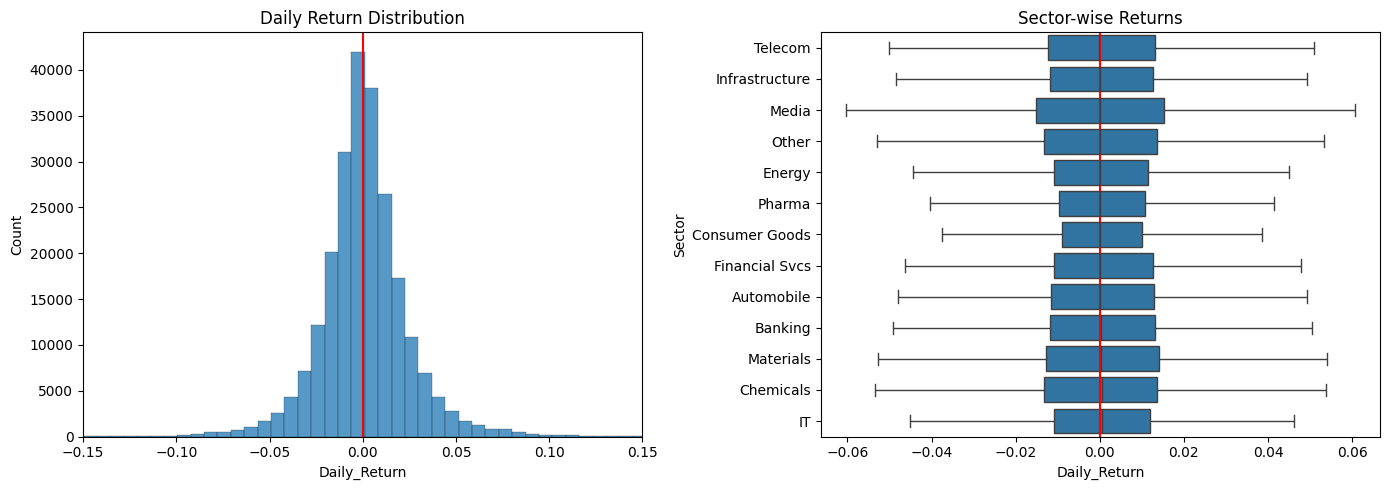

In [18]:
# Daily Return Distribution

df["Daily_Return"] = (
    df.groupby("Symbol")["Close"]
      .pct_change()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=200,
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="red"
)

axes[0].set_xlim(-0.15, 0.15)
axes[0].set_title("Daily Return Distribution")

ret_sector = (
    df[["Sector", "Daily_Return"]]
    .dropna()
)

order = (
    ret_sector.groupby("Sector")["Daily_Return"]
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=ret_sector,
    x="Daily_Return",
    y="Sector",
    order=order,
    showfliers=False,
    ax=axes[1]
)

axes[1].axvline(
    0,
    color="red"
)

axes[1].set_title(
    "Sector-wise Returns"
)

plt.tight_layout()
plt.show()

In [19]:
df["Date"] = pd.to_datetime(df["Date"])

In [20]:
print(df["Date"].dtype)

datetime64[ns]


/tmp/ipykernel_58/3160262866.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(axis=1)


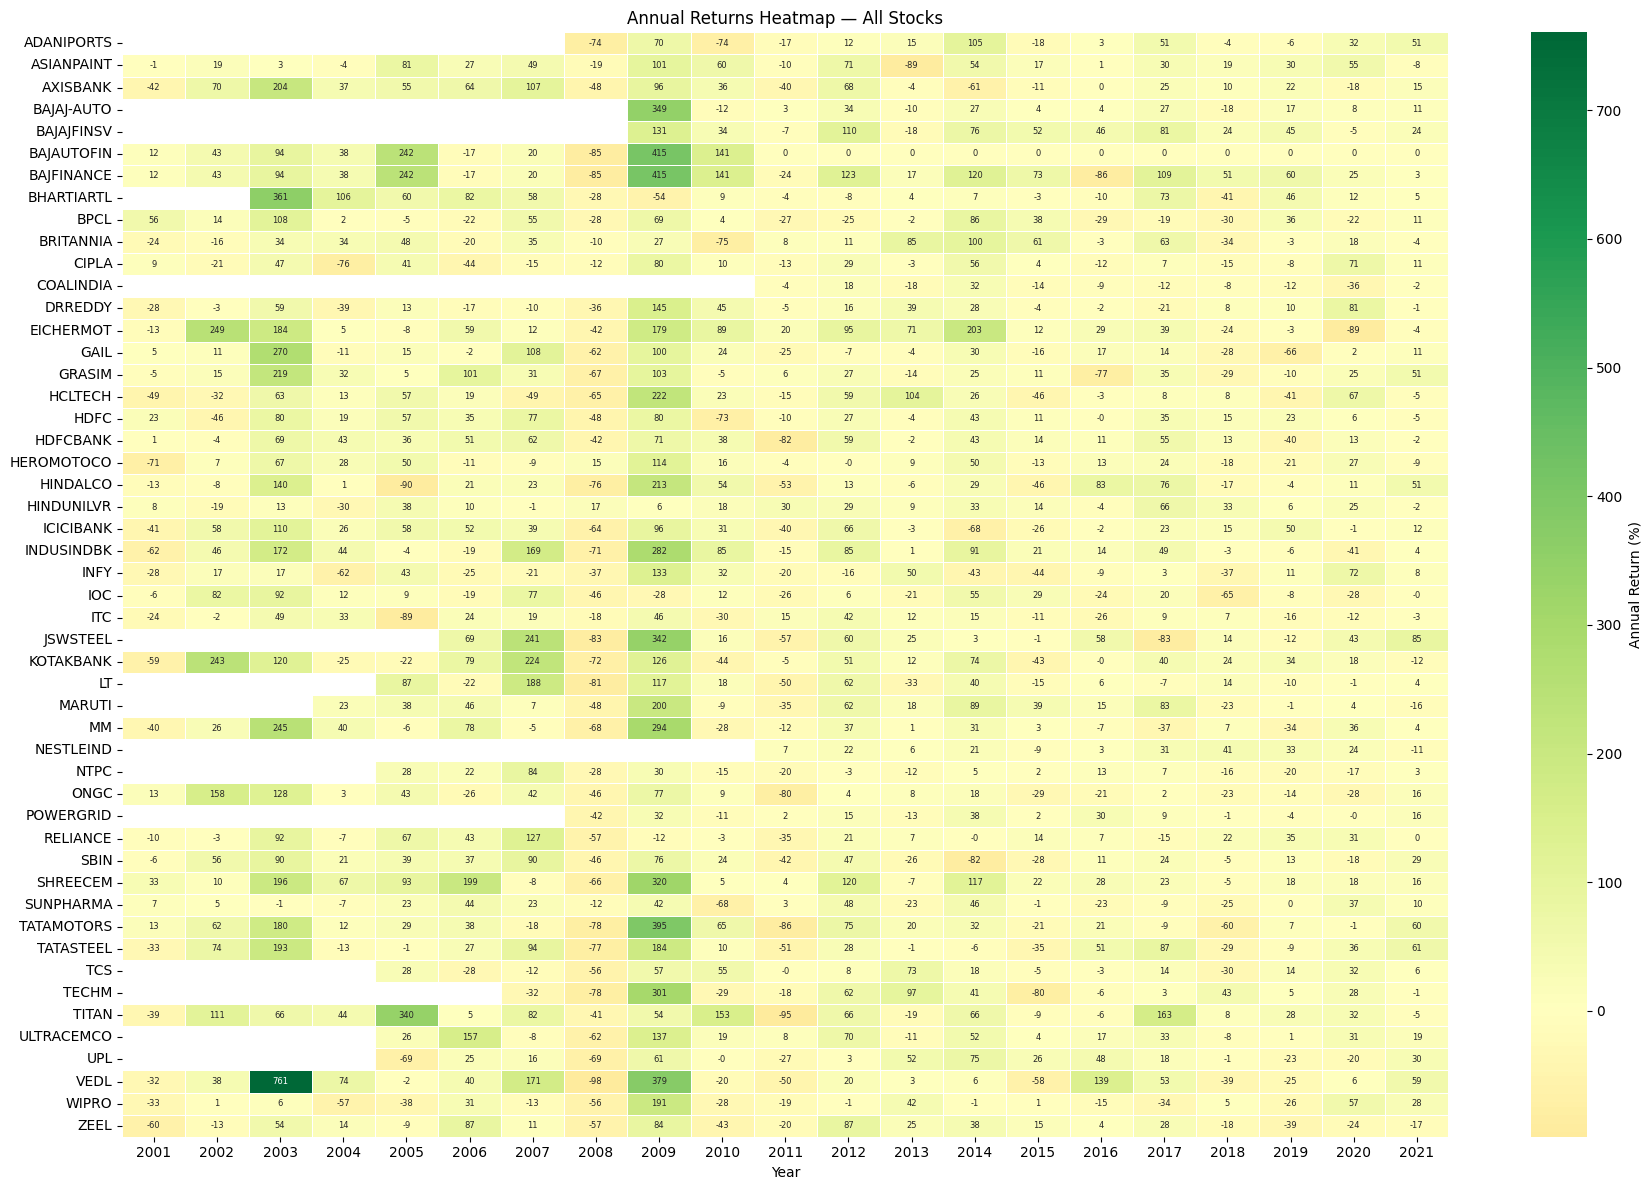

In [21]:
# Annual Return Heatmap

df["Year"] = df["Date"].dt.year

annual_ret = (
    df.groupby(["Symbol", "Year"])["Close"]
      .last()
      .unstack()
      .pct_change(axis=1)
      .iloc[:, 1:]
      .mul(100)
)

plt.figure(figsize=(18, 12))

sns.heatmap(
    annual_ret,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".0f",
    linewidths=0.4,
    annot_kws={"size": 6},
    cbar_kws={"label": "Annual Return (%)"}
)

plt.title("Annual Returns Heatmap — All Stocks")
plt.xlabel("Year")
plt.ylabel("")

plt.tight_layout()
plt.show()

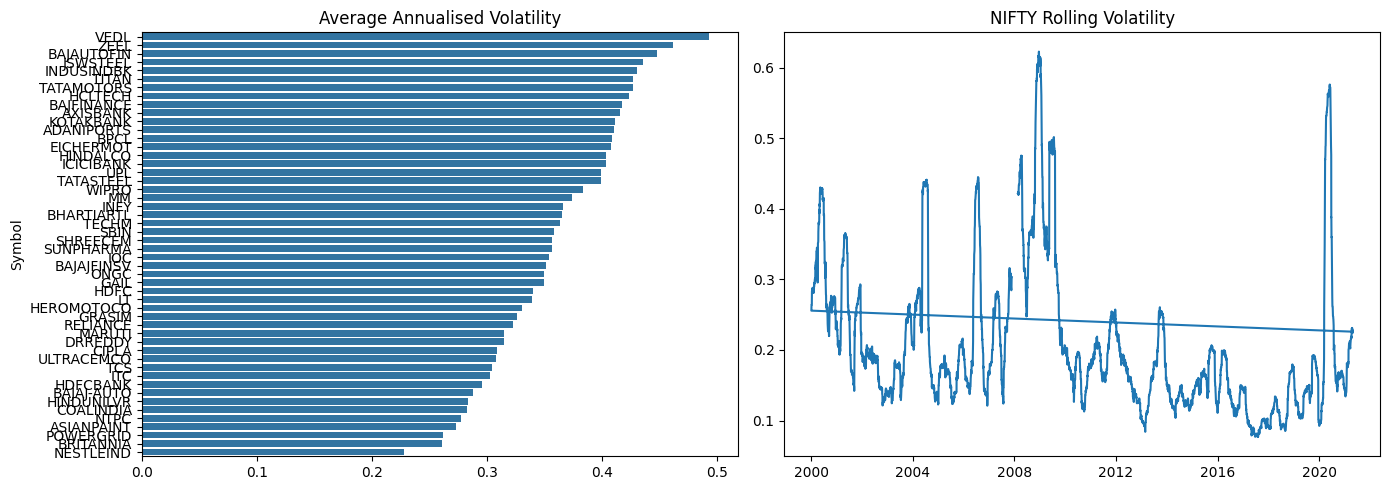

In [22]:
# Rolling Volatility

vol = (
    df.groupby("Symbol")["Daily_Return"]
      .apply(lambda x: x.rolling(20).std() * np.sqrt(252))
      .reset_index(level=0, drop=True)
)

df["Volatility_20d"] = vol

avg_vol = (
    df.groupby("Symbol")["Volatility_20d"]
      .mean()
      .sort_values(ascending=False)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    x=avg_vol.values,
    y=avg_vol.index,
    ax=axes[0]
)

axes[0].set_title("Average Annualised Volatility")

nifty_vol = (
    df.drop_duplicates("Date")
      .set_index("Date")["NIFTY_Return"]
      .rolling(60)
      .std()
      * np.sqrt(252)
)

axes[1].plot(
    nifty_vol.index,
    nifty_vol.values
)

axes[1].set_title(
    "NIFTY Rolling Volatility"
)

plt.tight_layout()
plt.show()

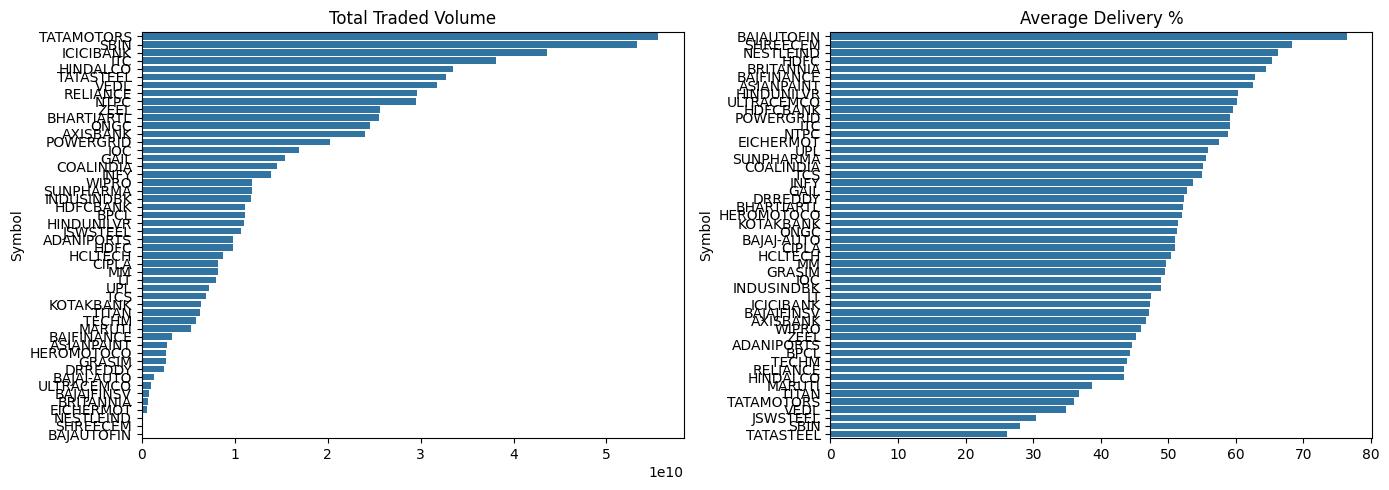

In [23]:
# Volume Analysis

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

total_vol = (
    df.groupby("Symbol")["Volume"]
      .sum()
      .sort_values(ascending=False)
)

sns.barplot(
    x=total_vol.values,
    y=total_vol.index,
    ax=axes[0]
)

axes[0].set_title(
    "Total Traded Volume"
)

avg_del = (
    df[df["DV_Missing"] == 0]
      .groupby("Symbol")["%Deliverble"]
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=avg_del.values * 100,
    y=avg_del.index,
    ax=axes[1]
)

axes[1].set_title(
    "Average Delivery %"
)

plt.tight_layout()
plt.show()

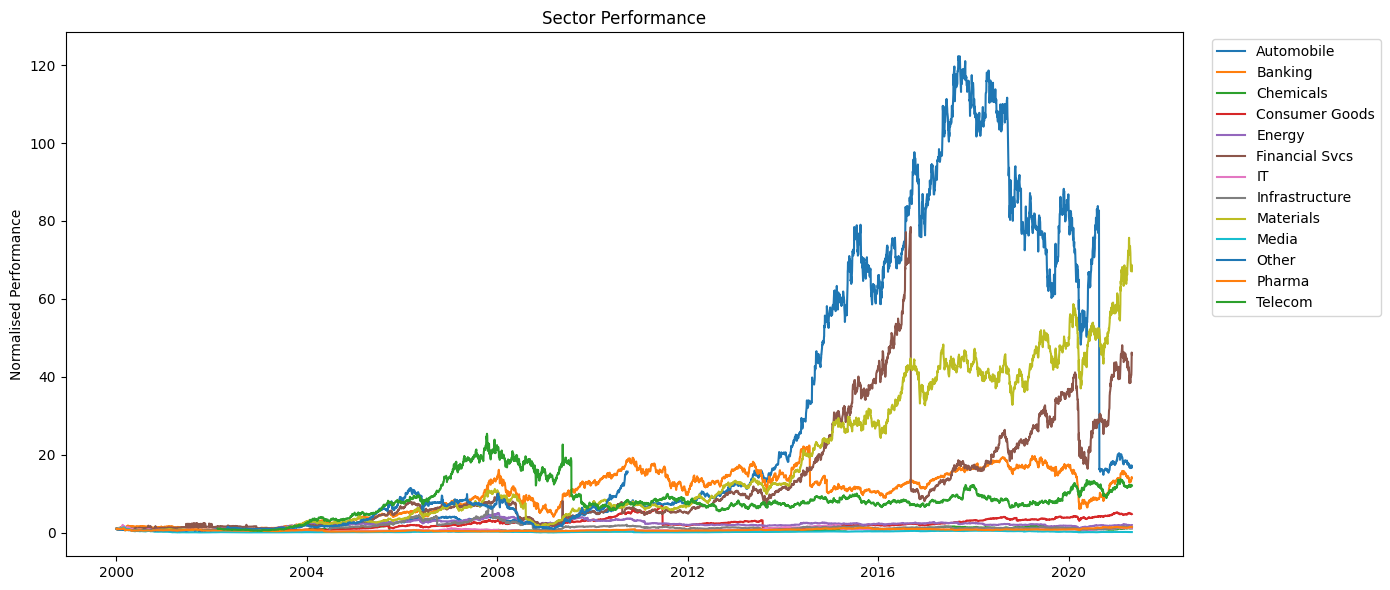

In [24]:
# Sector Performance

sector_returns = (
    norm.stack()
        .reset_index()
        .rename(
            columns={
                "level_1": "Symbol",
                0: "NormPrice"
            }
        )
        .merge(
            df[
                ["Symbol", "Sector"]
            ].drop_duplicates(),
            on="Symbol"
        )
)

sector_idx = (
    sector_returns
    .groupby(
        ["Date", "Sector"]
    )["NormPrice"]
    .mean()
    .unstack()
)

plt.figure(figsize=(14, 6))

for sector in sector_idx.columns:

    plt.plot(
        sector_idx.index,
        sector_idx[sector],
        label=sector
    )

plt.title(
    "Sector Performance"
)

plt.ylabel(
    "Normalised Performance"
)

plt.legend(
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

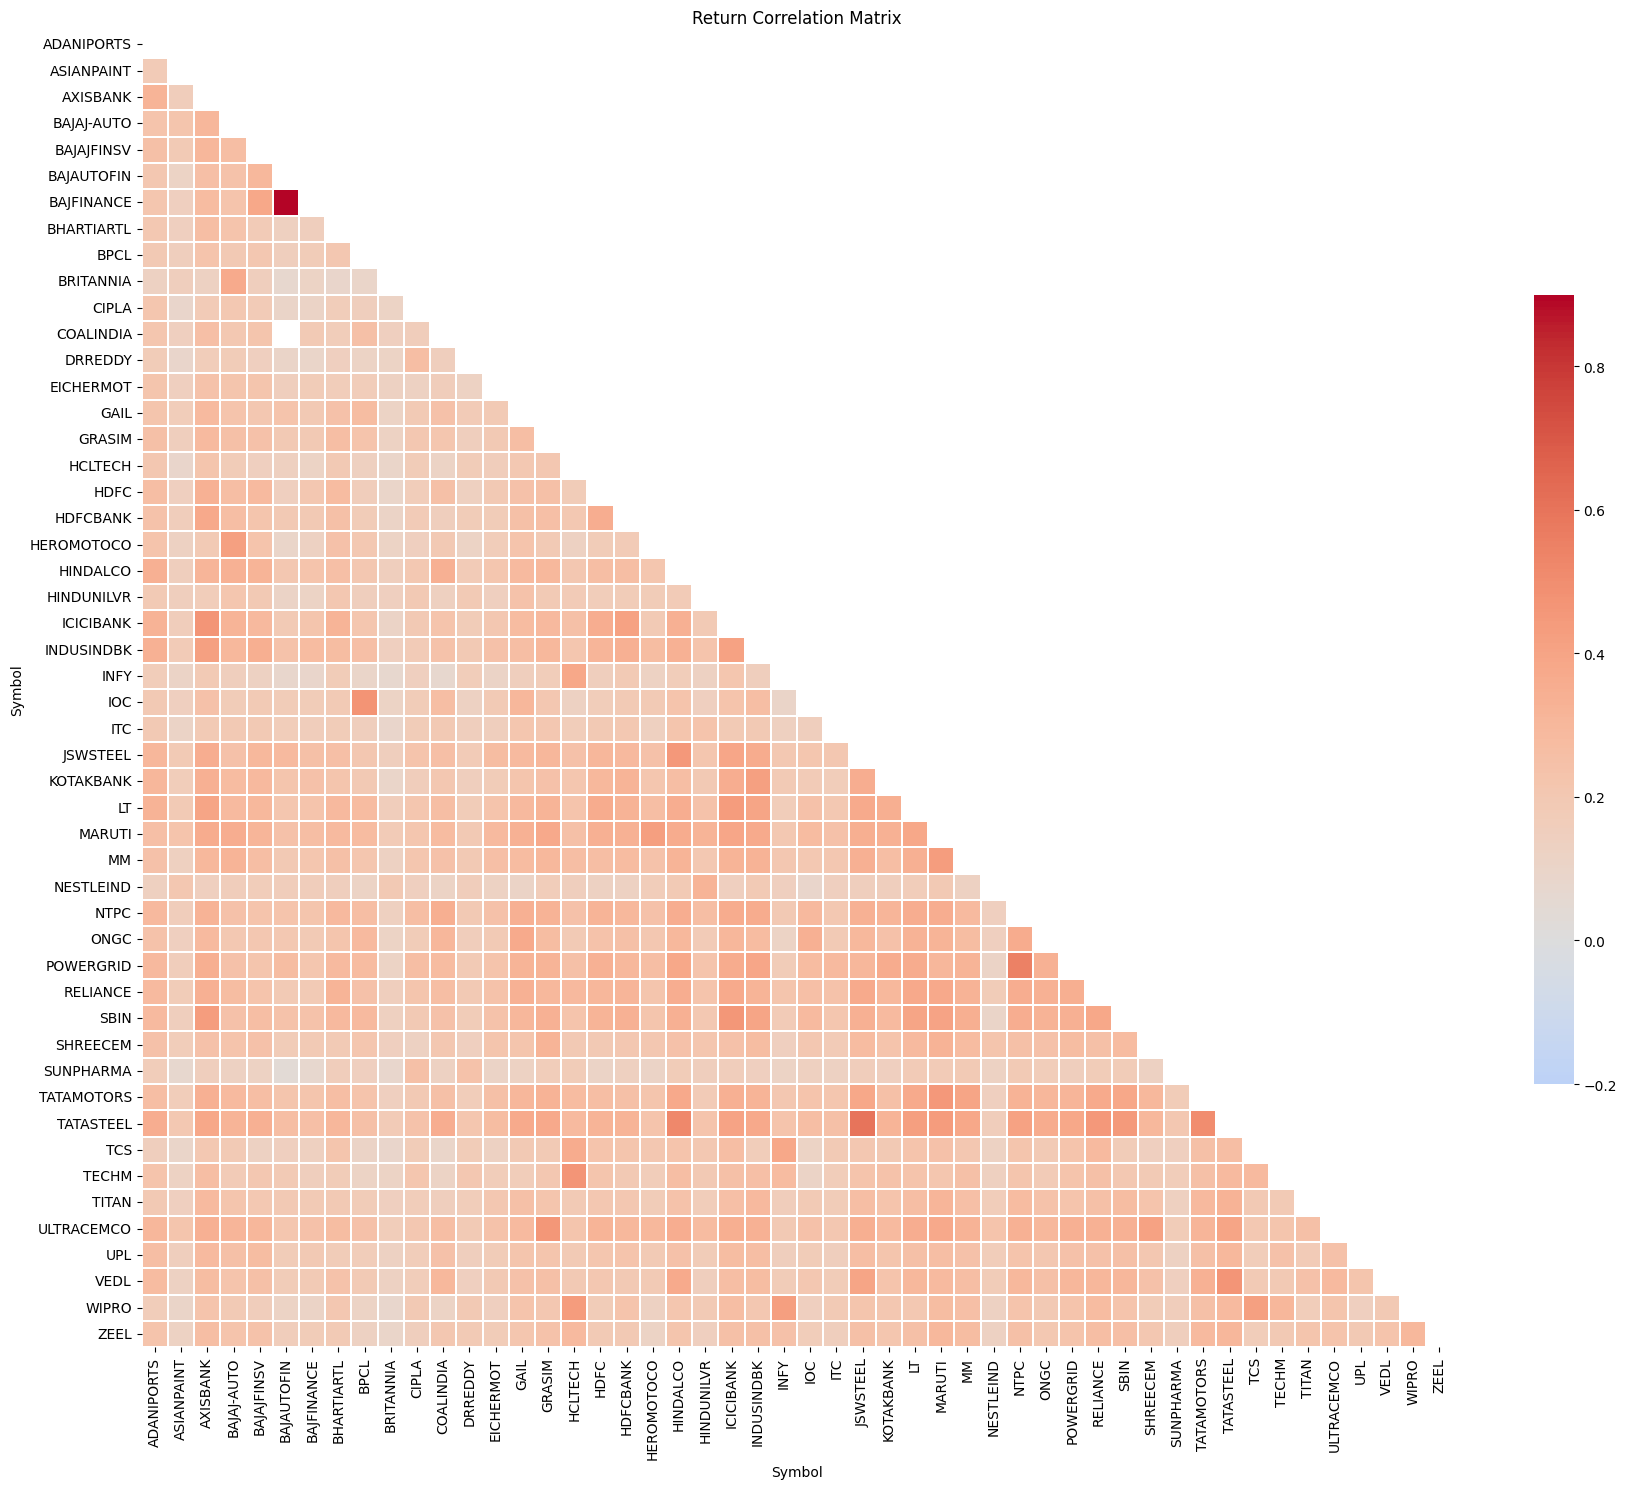

In [25]:
# Correlation Matrix

ret_pivot = df.pivot_table(
    index="Date",
    columns="Symbol",
    values="Daily_Return"
)

corr = ret_pivot.corr()

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-0.2,
    vmax=0.9,
    linewidths=0.3,
    cbar_kws={"shrink": 0.6}
)

plt.title(
    "Return Correlation Matrix"
)

plt.tight_layout()
plt.show()

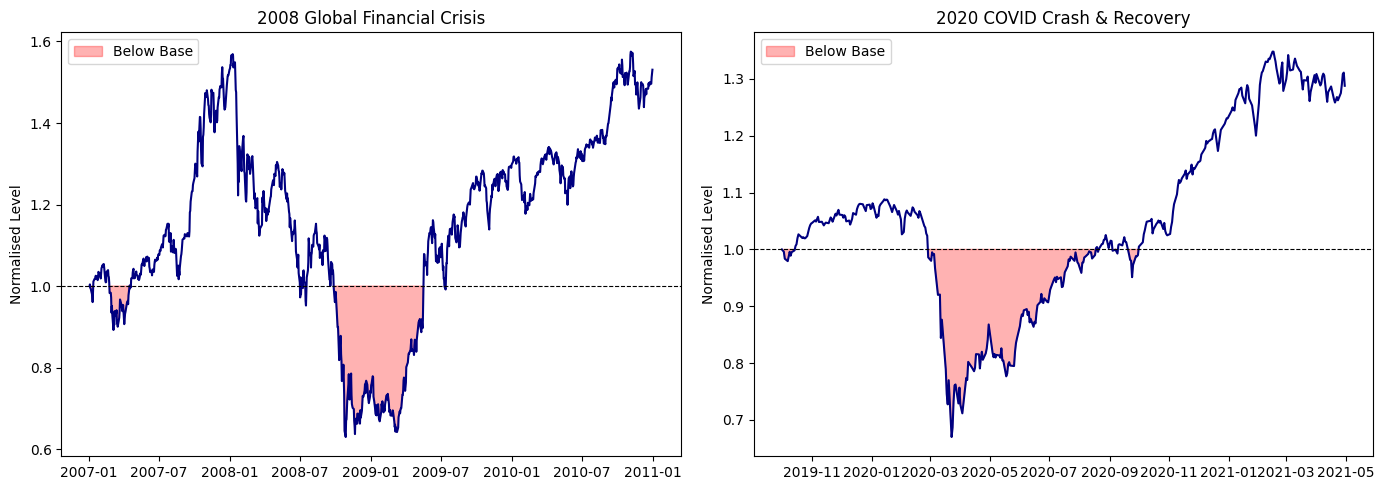

In [26]:
# Market Crash & Recovery Analysis

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

events = [
    (
        "2008 Global Financial Crisis",
        "2007-01-01",
        "2010-12-31"
    ),
    (
        "2020 COVID Crash & Recovery",
        "2019-10-01",
        "2021-04-30"
    )
]

for ax, (title, start, end) in zip(axes, events):

    event_idx = idx["NIFTY_Close"].loc[start:end]

    event_norm = (
        event_idx /
        event_idx.iloc[0]
    )

    ax.plot(
        event_norm.index,
        event_norm.values,
        lw=1.5,
        color="navy"
    )

    ax.fill_between(
        event_norm.index,
        event_norm.values,
        1,
        where=event_norm.values < 1,
        alpha=0.3,
        color="red",
        label="Below Base"
    )

    ax.axhline(
        1,
        color="black",
        linestyle="--",
        lw=0.8
    )

    ax.set_title(title)
    ax.set_ylabel("Normalised Level")
    ax.legend()

plt.tight_layout()
plt.show()

In [27]:
# 2008 Crisis

mask_2008 = (
    (df["Date"] >= "2008-01-01") &
    (df["Date"] <= "2009-03-31")
)

crash_2008 = (
    df[mask_2008]
    .groupby("Symbol")["Close"]
    .apply(
        lambda x:
        (x / x.iloc[0] - 1).min() * 100
    )
)

print("\n2008 Crisis — Worst 5 Stocks")
print(crash_2008.nsmallest(5).round(1))

print("\n2008 Crisis — Most Resilient 5 Stocks")
print(crash_2008.nlargest(5).round(1))


# COVID Crash

mask_covid = (
    (df["Date"] >= "2020-01-01") &
    (df["Date"] <= "2020-06-30")
)

crash_covid = (
    df[mask_covid]
    .groupby("Symbol")["Close"]
    .apply(
        lambda x:
        (x / x.iloc[0] - 1).min() * 100
    )
)

print("\nCOVID Crash — Worst 5 Stocks")
print(crash_covid.nsmallest(5).round(1))

print("\nCOVID Crash — Most Resilient 5 Stocks")
print(crash_covid.nlargest(5).round(1))


2008 Crisis — Worst 5 Stocks
Symbol
VEDL         -98.4
BAJAUTOFIN   -88.8
BAJFINANCE   -88.8
JSWSTEEL     -87.6
LT           -86.4
Name: Close, dtype: float64

2008 Crisis — Most Resilient 5 Stocks
Symbol
HEROMOTOCO   -15.1
HINDUNILVR   -15.7
SUNPHARMA    -22.7
CIPLA        -24.2
BRITANNIA    -25.6
Name: Close, dtype: float64

COVID Crash — Worst 5 Stocks
Symbol
INDUSINDBK   -79.7
TATAMOTORS   -64.6
VEDL         -60.2
AXISBANK     -59.5
HINDALCO     -59.0
Name: Close, dtype: float64

COVID Crash — Most Resilient 5 Stocks
Symbol
HINDUNILVR    -5.1
DRREDDY       -8.9
BHARTIARTL   -10.9
NESTLEIND    -12.4
ASIANPAINT   -16.4
Name: Close, dtype: float64


/tmp/ipykernel_58/1778379511.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


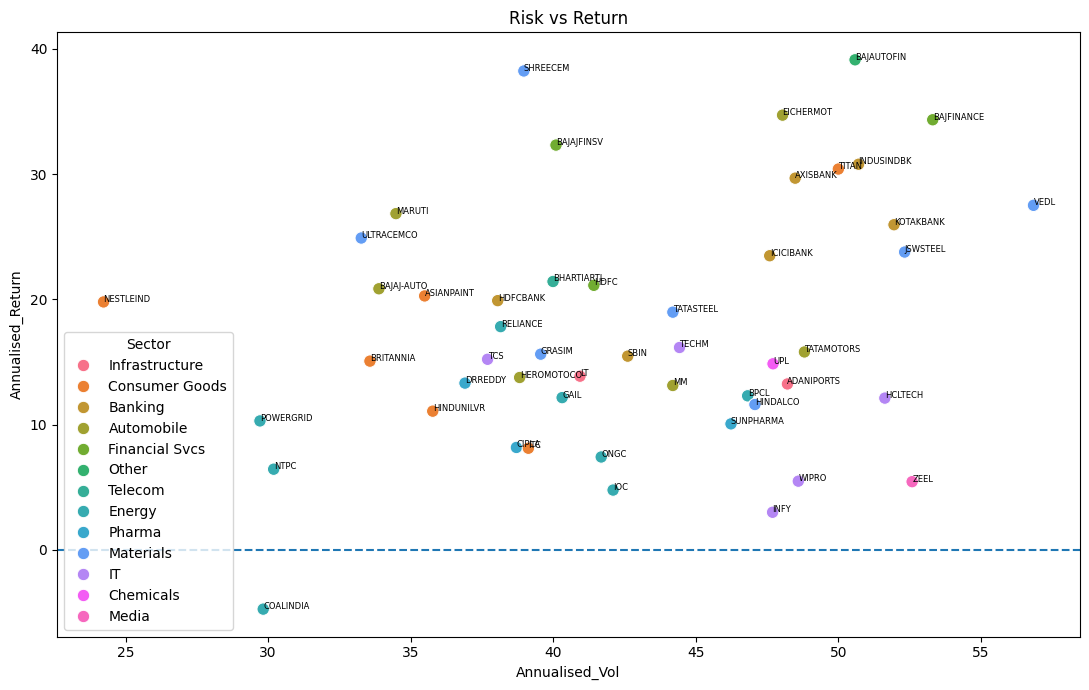

In [28]:
# Risk vs Return

stock_summary = (
    df.groupby("Symbol")
      .apply(
          lambda g: pd.Series({
              "Annualised_Return":
                  g["Daily_Return"].mean() * 252 * 100,

              "Annualised_Vol":
                  g["Daily_Return"].std() * np.sqrt(252) * 100,

              "Sector":
                  g["Sector"].iloc[0]
          })
      )
      .reset_index()
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=stock_summary,
    x="Annualised_Vol",
    y="Annualised_Return",
    hue="Sector",
    s=80
)

for _, row in stock_summary.iterrows():

    plt.text(
        row["Annualised_Vol"],
        row["Annualised_Return"],
        row["Symbol"],
        fontsize=6
    )

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Risk vs Return"
)

plt.tight_layout()
plt.show()

<Axes: ylabel='Sector'>

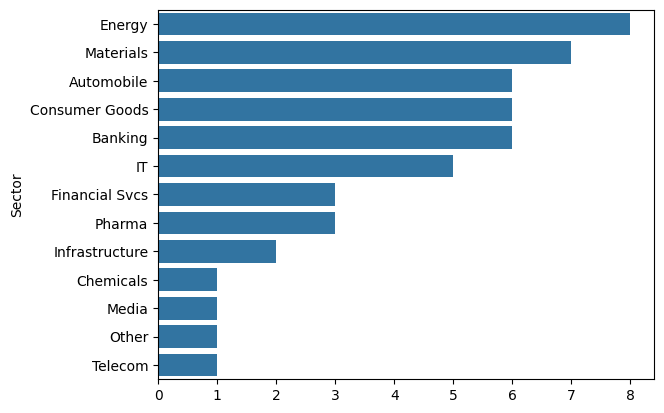

In [29]:
sector_cnt = (
    df.groupby("Sector")["Symbol"]
      .nunique()
      .sort_values(ascending=False)
)

sns.barplot(
    x=sector_cnt.values,
    y=sector_cnt.index
)

In [30]:
stock_summary.sort_values(
    "Annualised_Return",
    ascending=False
)

,Symbol,Annualised_Return,Annualised_Vol,Sector
5,BAJAUTOFIN,39.121099,50.583114,Other
38,SHREECEM,38.229566,38.966486,Materials
13,EICHERMOT,34.703992,48.039932,Automobile
6,BAJFINANCE,34.335608,53.306653,Financial Svcs
4,BAJAJFINSV,32.314853,40.093958,Financial Svcs
23,INDUSINDBK,30.784041,50.705604,Banking
44,TITAN,30.401606,49.996802,Consumer Goods
2,AXISBANK,29.673082,48.483044,Banking
47,VEDL,27.505434,56.841099,Materials
30,MARUTI,26.843002,34.480620,Automobile


In [31]:
stock_summary.sort_values(
    "Annualised_Vol",
    ascending=False
)

,Symbol,Annualised_Return,Annualised_Vol,Sector
47,VEDL,27.505434,56.841099,Materials
6,BAJFINANCE,34.335608,53.306653,Financial Svcs
49,ZEEL,5.446288,52.584374,Media
27,JSWSTEEL,23.775695,52.321419,Materials
28,KOTAKBANK,25.956558,51.948703,Banking
16,HCLTECH,12.116783,51.627070,IT
23,INDUSINDBK,30.784041,50.705604,Banking
5,BAJAUTOFIN,39.121099,50.583114,Other
44,TITAN,30.401606,49.996802,Consumer Goods
40,TATAMOTORS,15.802189,48.807330,Automobile


In [32]:
# Correlation of each stock with NIFTY returns

nifty_ret = (
    df.drop_duplicates("Date")
      .set_index("Date")["NIFTY_Return"]
)

corr_nifty = (
    ret_pivot.corrwith(nifty_ret)
    .sort_values(ascending=False)
)

print("Top 10 Most Correlated with NIFTY")
print(corr_nifty.head(10))

print("\nTop 10 Least Correlated with NIFTY")
print(corr_nifty.tail(10))

Top 10 Most Correlated with NIFTY
Symbol
RELIANCE      0.669972
TATASTEEL     0.663410
LT            0.614754
MARUTI        0.609867
SBIN          0.608684
ICICIBANK     0.606788
NTPC          0.580598
POWERGRID     0.571203
TATAMOTORS    0.566918
JSWSTEEL      0.557989
dtype: float64

Top 10 Least Correlated with NIFTY
Symbol
EICHERMOT     0.356739
CIPLA         0.354942
HEROMOTOCO    0.354281
DRREDDY       0.331356
BAJAUTOFIN    0.310561
NESTLEIND     0.309739
SUNPHARMA     0.297358
BAJFINANCE    0.289668
ASIANPAINT    0.267762
BRITANNIA     0.234431
dtype: float64


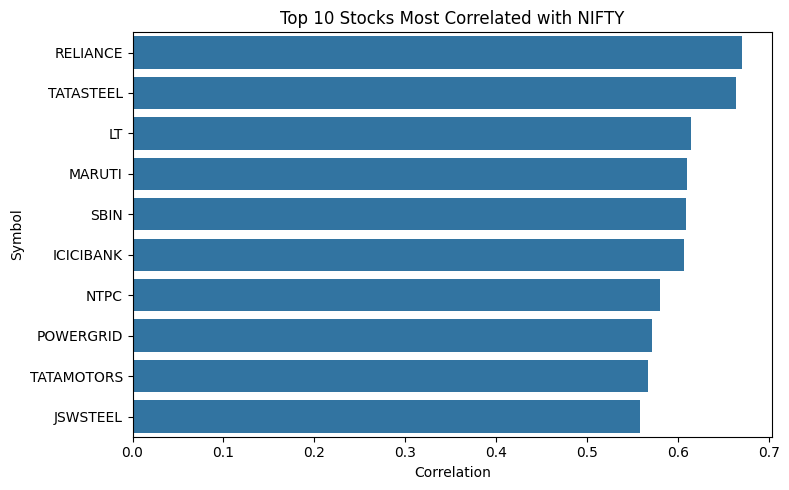

In [33]:
top_corr = corr_nifty.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top 10 Stocks Most Correlated with NIFTY")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

In [34]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)
df["Date"].dtype
df.shape

(237803, 31)

In [35]:
price_jump = (
    df.groupby("Symbol")["Close"]
      .pct_change()
      .abs()
)

In [36]:
print(
    "Rows with >50% daily jump:",
    (price_jump > 0.50).sum()
)

Rows with >50% daily jump: 57


In [37]:
df = df[
    (price_jump <= 0.50) |
    (price_jump.isna())
].copy()

df = df.reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (237746, 31)


In [38]:
# Master Function

def compute_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("Date").copy()

    # Returns
    g["Return_1d"] = g["Close"].pct_change(1)
    g["Return_5d"] = g["Close"].pct_change(5)
    g["Return_22d"] = g["Close"].pct_change(22)
    g["Log_Return"] = np.log(g["Close"] / g["Close"].shift(1))
    g["Direction"] = np.sign(g["Return_1d"])

    # Simple Moving Averages
    for w in [5, 10, 20, 50, 200]:
        g[f"SMA_{w}"] = g["Close"].rolling(w, min_periods=w).mean()

    # Exponential Moving Averages
    for s in [12, 26, 50]:
        g[f"EMA_{s}"] = g["Close"].ewm(span=s, adjust=False).mean()

    # MACD
    g["MACD"] = g["EMA_12"] - g["EMA_26"]
    g["MACD_Signal"] = g["MACD"].ewm(span=9, adjust=False).mean()
    g["MACD_Hist"] = g["MACD"] - g["MACD_Signal"]

    # RSI
    delta = g["Close"].diff()
    avg_gain = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    avg_loss = (-delta).clip(lower=0).rolling(14, min_periods=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    g["RSI"] = 100 - (100 / (1 + rs))

    # Bollinger Bands
    mid = g["Close"].rolling(20).mean()
    std = g["Close"].rolling(20).std()
    g["BB_Mid"] = mid
    g["BB_Upper"] = mid + 2 * std
    g["BB_Lower"] = mid - 2 * std
    g["BB_Width"] = (g["BB_Upper"] - g["BB_Lower"]) / mid.replace(0, np.nan)
    band_range = (g["BB_Upper"] - g["BB_Lower"]).replace(0, np.nan)
    g["BB_Pct"] = (g["Close"] - g["BB_Lower"]) / band_range

    # ATR
    prev_close = g["Close"].shift(1)
    tr = pd.concat([
        g["High"] - g["Low"],
        (g["High"] - prev_close).abs(),
        (g["Low"] - prev_close).abs()
    ], axis=1).max(axis=1)
    g["ATR"] = tr.rolling(14, min_periods=14).mean()

    # Stochastic Oscillator
    low14 = g["Low"].rolling(14).min()
    high14 = g["High"].rolling(14).max()
    rng14 = (high14 - low14).replace(0, np.nan)
    g["Stoch_K"] = (g["Close"] - low14) / rng14 * 100
    g["Stoch_D"] = g["Stoch_K"].rolling(3).mean()

    # OBV
    direction = np.sign(g["Close"].diff())
    g["OBV"] = (direction * g["Volume"]).fillna(0).cumsum()

    # Volatility
    g["Volatility_20d"] = g["Return_1d"].rolling(20).std()
    g["Volatility_Ann"] = g["Return_1d"].rolling(252).std() * np.sqrt(252)

    # Volume indicators
    g["Vol_SMA_20"] = g["Volume"].rolling(20).mean()
    g["Vol_Ratio"] = g["Volume"] / g["Vol_SMA_20"].replace(0, np.nan)
    g["Vol_Spike"] = (g["Vol_Ratio"] > 2).astype(int)

    # Price vs moving averages
    g["Above_SMA20"] = (g["Close"] > g["SMA_20"]).astype(int)
    g["Above_SMA50"] = (g["Close"] > g["SMA_50"]).astype(int)
    g["Above_SMA200"] = (g["Close"] > g["SMA_200"]).astype(int)

    # Signal flags
    g["Golden_Cross"] = (
        (g["SMA_50"] > g["SMA_200"]) &
        (g["SMA_50"].shift(1) <= g["SMA_200"].shift(1))
    ).astype(int)

    g["Death_Cross"] = (
        (g["SMA_50"] < g["SMA_200"]) &
        (g["SMA_50"].shift(1) >= g["SMA_200"].shift(1))
    ).astype(int)

    g["MACD_Cross_Up"] = (
        (g["MACD"] > g["MACD_Signal"]) &
        (g["MACD"].shift(1) <= g["MACD_Signal"].shift(1))
    ).astype(int)

    g["RSI_Overbought"] = (g["RSI"] > 70).astype(int)
    g["RSI_Oversold"] = (g["RSI"] < 30).astype(int)

    # Rolling Beta vs NIFTY
    cov = g["Return_1d"].rolling(252).cov(g["NIFTY_Return"])
    var = g["NIFTY_Return"].rolling(252).var()
    g["Beta_252d"] = cov / var.replace(0, np.nan)

    # Rolling Sharpe
    rf_daily = 0.06 / 252
    excess = g["Return_1d"] - rf_daily
    g["Sharpe_252d"] = (
        excess.rolling(252).mean() /
        excess.rolling(252).std().replace(0, np.nan) *
        np.sqrt(252)
    )

    # Rolling Max Drawdown
    roll_max = g["Close"].cummax()
    drawdown = (g["Close"] - roll_max) / roll_max.replace(0, np.nan)
    g["MaxDrawdown_252d"] = drawdown.rolling(252).min()

    # 52-week High / Low
    g["High_52w"] = g["High"].rolling(252).max()
    g["Low_52w"] = g["Low"].rolling(252).min()
    rng52 = (g["High_52w"] - g["Low_52w"]).replace(0, np.nan)
    g["Pct_52w"] = (g["Close"] - g["Low_52w"]) / rng52

    # Momentum
    g["ROC_10"] = g["Close"].pct_change(10)
    g["ROC_20"] = g["Close"].pct_change(20)

    # Intraday Range
    g["HL_Range"] = (g["High"] - g["Low"]) / g["Close"].replace(0, np.nan)

    # Targets
    g["Target_1d"] = g["Return_1d"].shift(-1)
    g["Target_5d"] = g["Return_5d"].shift(-5)
    g["Target_Dir"] = (g["Target_1d"] > 0).astype(float)

    return g

In [39]:
parts = []
for sym, grp in df.groupby("Symbol"):
    parts.append(compute_features(grp))

df_feat = pd.concat(parts, ignore_index=True)
df_feat = df_feat.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(f"Shape: {df_feat.shape} | Features: {df_feat.shape[1]}")

Shape: (237746, 81) | Features: 81


In [40]:
# Adding Time & Calendar Features

df_feat["Year"] = df_feat["Date"].dt.year
df_feat["Month"] = df_feat["Date"].dt.month
df_feat["Quarter"] = df_feat["Date"].dt.quarter
df_feat["DayOfWeek"] = df_feat["Date"].dt.dayofweek
df_feat["IsMonday"] = (df_feat["DayOfWeek"] == 0).astype(int)
df_feat["IsFriday"] = (df_feat["DayOfWeek"] == 4).astype(int)
print("Calendar features added")

Calendar features added


In [41]:
# Feature Summary

feature_groups = {
    "Raw Price": ["Open", "High", "Low", "Close", "VWAP", "Prev Close"],
    "Returns": ["Return_1d", "Return_5d", "Return_22d", "Log_Return"],
    "Moving Averages": [f"SMA_{w}" for w in [5, 10, 20, 50, 200]] + [f"EMA_{s}" for s in [12, 26, 50]],
    "MACD": ["MACD", "MACD_Signal", "MACD_Hist"],
    "RSI": ["RSI"],
    "Bollinger Bands": ["BB_Upper", "BB_Mid", "BB_Lower", "BB_Width", "BB_Pct"],
    "ATR & Stochastic": ["ATR", "Stoch_K", "Stoch_D"],
    "Volume": ["Volume", "OBV", "Vol_SMA_20", "Vol_Ratio", "Vol_Spike"],
    "Volatility": ["Volatility_20d", "Volatility_Ann"],
    "Risk": ["Beta_252d", "Sharpe_252d", "MaxDrawdown_252d"],
    "Signals": [
        "Golden_Cross", "Death_Cross", "MACD_Cross_Up",
        "RSI_Overbought", "RSI_Oversold",
        "Above_SMA20", "Above_SMA50", "Above_SMA200"
    ],
    "Momentum": ["ROC_10", "ROC_20", "Pct_52w"],
    "NIFTY Context": ["NIFTY_Close", "NIFTY_Return", "Beta_252d"],
    "Targets (ML)": ["Target_1d", "Target_5d", "Target_Dir"],
    "Calendar": ["Year", "Month", "Quarter", "DayOfWeek"]
}

In [42]:
print(f"{'Group':<20} {'Features':>8}   Columns")

for grp, cols in feature_groups.items():
    existing = [c for c in cols if c in df_feat.columns]
    print(f"{grp:<20} {len(existing):>8}   {existing}")

f"Total columns: {df_feat.shape[1]}"

Group                Features   Columns
Raw Price                   6   ['Open', 'High', 'Low', 'Close', 'VWAP', 'Prev Close']
Returns                     4   ['Return_1d', 'Return_5d', 'Return_22d', 'Log_Return']
Moving Averages             8   ['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'EMA_50']
MACD                        3   ['MACD', 'MACD_Signal', 'MACD_Hist']
RSI                         1   ['RSI']
Bollinger Bands             5   ['BB_Upper', 'BB_Mid', 'BB_Lower', 'BB_Width', 'BB_Pct']
ATR & Stochastic            3   ['ATR', 'Stoch_K', 'Stoch_D']
Volume                      5   ['Volume', 'OBV', 'Vol_SMA_20', 'Vol_Ratio', 'Vol_Spike']
Volatility                  2   ['Volatility_20d', 'Volatility_Ann']
Risk                        3   ['Beta_252d', 'Sharpe_252d', 'MaxDrawdown_252d']
Signals                     8   ['Golden_Cross', 'Death_Cross', 'MACD_Cross_Up', 'RSI_Overbought', 'RSI_Oversold', 'Above_SMA20', 'Above_SMA50', 'Above_SMA200']
Momentum    

'Total columns: 86'

In [43]:
# Null % Check

nulls = df_feat.isnull().mean().mul(100).round(1)

print("Null % per feature (> 0.5% only):")
print(nulls[nulls > 0.5].sort_values(ascending=False).to_string())

print()
print(f"Total rows: {len(df_feat):,}")
print("These NaNs are expected for rolling indicators and future targets.")

Null % per feature (> 0.5% only):
Volatility_Ann      5.3
Low_52w             5.3
Beta_252d           5.3
Sharpe_252d         5.3
MaxDrawdown_252d    5.3
Pct_52w             5.3
High_52w            5.3
SMA_200             4.2
SMA_50              1.0

Total rows: 237,746
These NaNs are expected for rolling indicators and future targets.


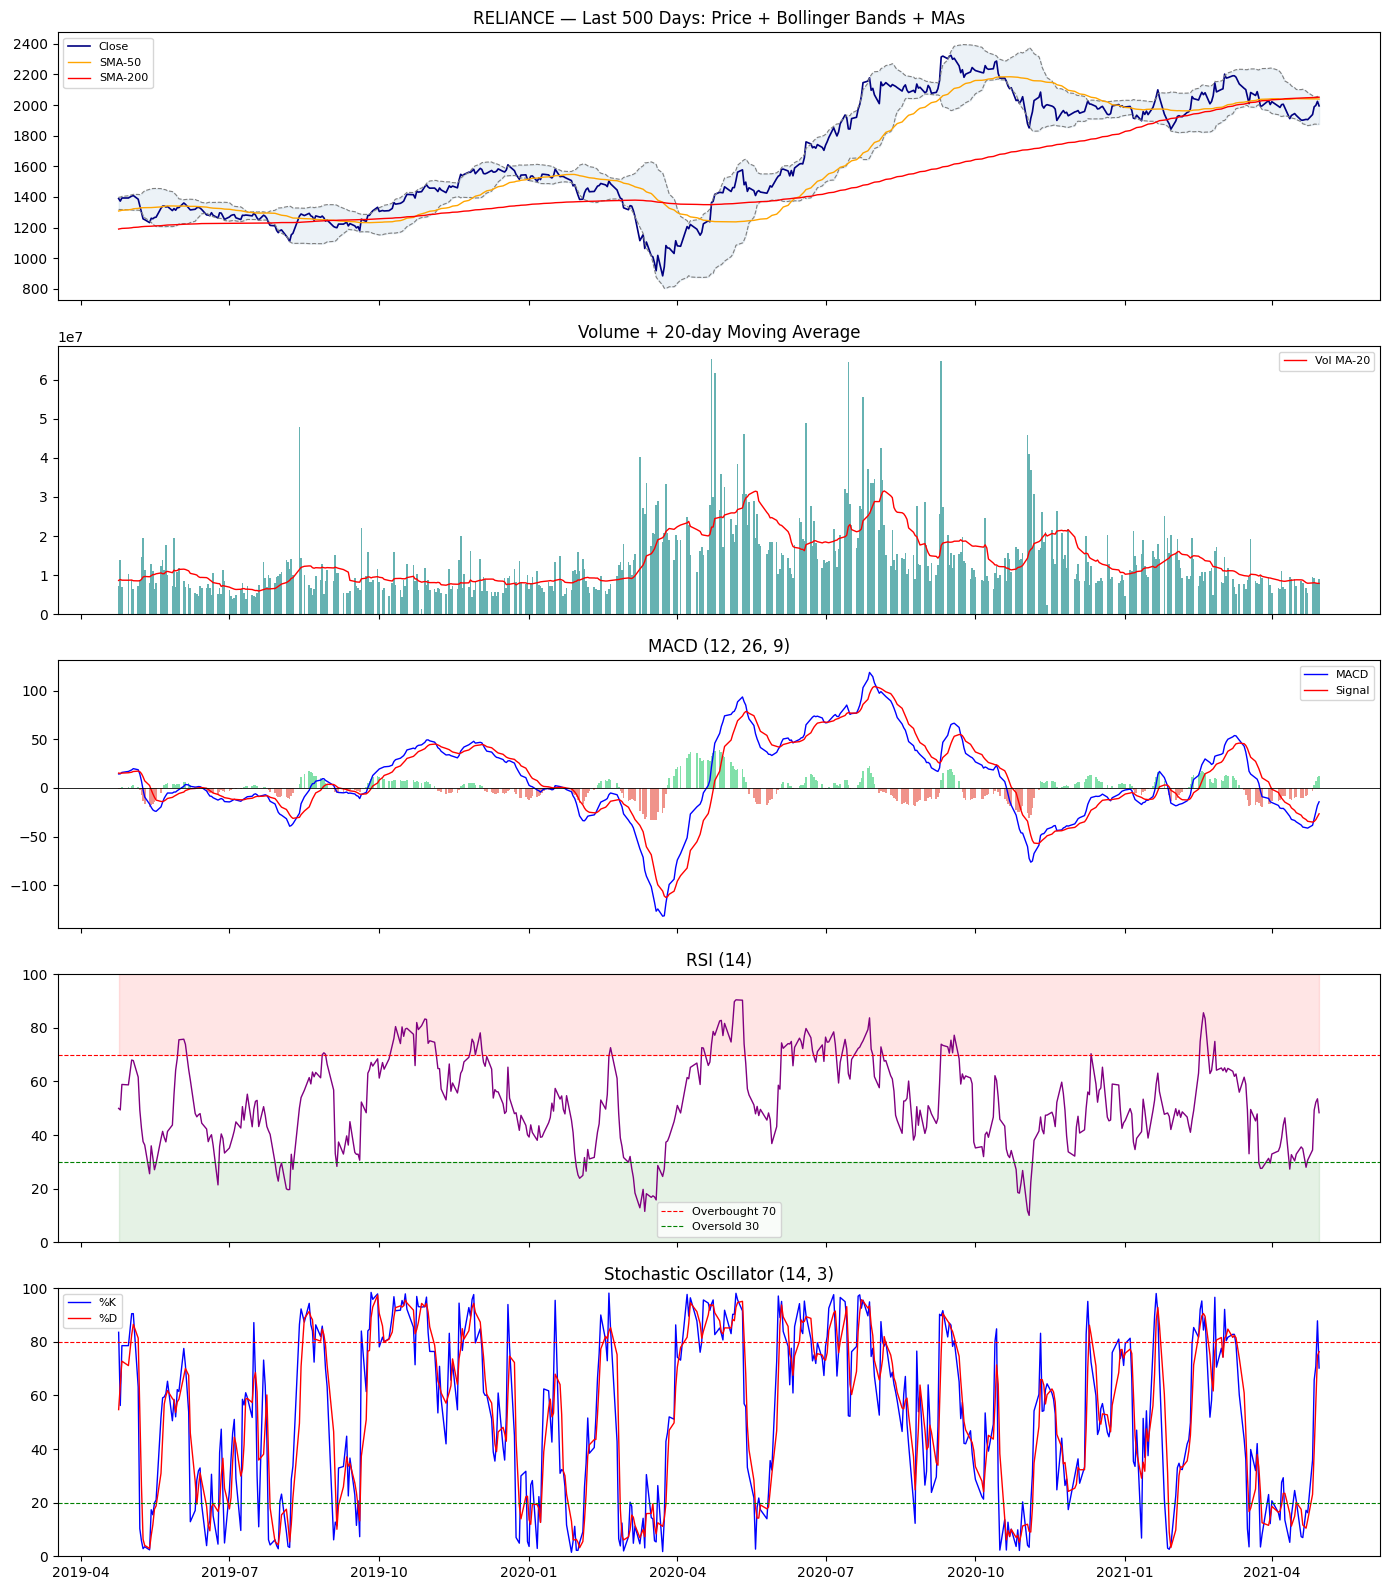

In [44]:
# Quick Indicator Sanity Plot (sample: RELIANCE)

sample = df_feat[df_feat["Symbol"] == "RELIANCE"].tail(500)

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Price + Bollinger + SMAs
axes[0].plot(sample["Date"], sample["Close"], lw=1.2, label="Close", color="navy")
axes[0].plot(sample["Date"], sample["BB_Upper"], lw=0.8, color="gray", linestyle="--")
axes[0].plot(sample["Date"], sample["BB_Lower"], lw=0.8, color="gray", linestyle="--")
axes[0].fill_between(sample["Date"], sample["BB_Lower"], sample["BB_Upper"], alpha=0.1, color="steelblue")
axes[0].plot(sample["Date"], sample["SMA_50"], lw=1, color="orange", label="SMA-50")
axes[0].plot(sample["Date"], sample["SMA_200"], lw=1, color="red", label="SMA-200")
axes[0].set_title("RELIANCE — Last 500 Days: Price + Bollinger Bands + MAs")
axes[0].legend(fontsize=8)

# Volume
axes[1].bar(sample["Date"], sample["Volume"], color="teal", alpha=0.6, width=1)
axes[1].plot(sample["Date"], sample["Vol_SMA_20"], color="red", lw=1, label="Vol MA-20")
axes[1].set_title("Volume + 20-day Moving Average")
axes[1].legend(fontsize=8)

# MACD
axes[2].plot(sample["Date"], sample["MACD"], color="blue", lw=1, label="MACD")
axes[2].plot(sample["Date"], sample["MACD_Signal"], color="red", lw=1, label="Signal")
axes[2].bar(
    sample["Date"],
    sample["MACD_Hist"],
    color=np.where(sample["MACD_Hist"] >= 0, "#2ecc71", "#e74c3c"),
    alpha=0.6,
    width=1
)
axes[2].axhline(0, color="black", lw=0.6)
axes[2].set_title("MACD (12, 26, 9)")
axes[2].legend(fontsize=8)

# RSI
axes[3].plot(sample["Date"], sample["RSI"], color="purple", lw=1)
axes[3].axhline(70, color="red", lw=0.8, linestyle="--", label="Overbought 70")
axes[3].axhline(30, color="green", lw=0.8, linestyle="--", label="Oversold 30")
axes[3].fill_between(sample["Date"], 70, 100, alpha=0.1, color="red")
axes[3].fill_between(sample["Date"], 0, 30, alpha=0.1, color="green")
axes[3].set_ylim(0, 100)
axes[3].set_title("RSI (14)")
axes[3].legend(fontsize=8)

# Stochastic
axes[4].plot(sample["Date"], sample["Stoch_K"], color="blue", lw=1, label="%K")
axes[4].plot(sample["Date"], sample["Stoch_D"], color="red", lw=1, label="%D")
axes[4].axhline(80, color="red", lw=0.8, linestyle="--")
axes[4].axhline(20, color="green", lw=0.8, linestyle="--")
axes[4].set_ylim(0, 100)
axes[4].set_title("Stochastic Oscillator (14, 3)")
axes[4].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [45]:
# Risk Metrics Summary

risk_summary = df_feat.groupby("Symbol").apply(lambda g: pd.Series({
    "Annualised_Return_%": round(g["Return_1d"].mean() * 252 * 100, 2),
    "Annualised_Vol_%": round(g["Return_1d"].std() * np.sqrt(252) * 100, 2),
    "Sharpe_Overall": round(
        (g["Return_1d"].mean() - 0.06 / 252) / g["Return_1d"].std() * np.sqrt(252), 2
    ),
    "Max_Drawdown_%": round(((g["Close"] / g["Close"].cummax()) - 1).min() * 100, 2),
    "Avg_Beta": round(g["Beta_252d"].mean(), 3),
    "Sector": g["Sector"].iloc[0],
})).reset_index()

risk_summary = risk_summary.sort_values("Sharpe_Overall", ascending=False)

print("Risk Summary — Top 10 by Sharpe Ratio:")
print(risk_summary.head(10).to_string(index=False))
print()
print("Risk Summary — Bottom 10 by Sharpe Ratio:")
print(risk_summary.tail(10).to_string(index=False))

Risk Summary — Top 10 by Sharpe Ratio:
    Symbol  Annualised_Return_%  Annualised_Vol_%  Sharpe_Overall  Max_Drawdown_%  Avg_Beta         Sector
  SHREECEM                38.23             38.97            0.83          -79.97     0.741      Materials
BAJFINANCE                39.03             48.67            0.68          -93.28     0.862 Financial Svcs
BAJAJFINSV                32.31             40.09            0.66          -86.79     0.905 Financial Svcs
BAJAUTOFIN                39.12             50.58            0.65          -91.80     0.571          Other
    MARUTI                26.84             34.48            0.60          -61.34     0.969     Automobile
 EICHERMOT                34.63             48.03            0.60          -93.82     0.809     Automobile
 NESTLEIND                19.79             24.23            0.57          -32.40     0.421 Consumer Goods
ULTRACEMCO                24.90             33.26            0.57          -77.78     0.892      Material

/tmp/ipykernel_58/3970534899.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_summary = df_feat.groupby("Symbol").apply(lambda g: pd.Series({


In [46]:
df_feat.to_csv("master_features.csv", index=False)

print(f"Saved: master_features.csv")
print(f"Shape : {df_feat.shape}")

Saved: master_features.csv
Shape : (237746, 86)


In [47]:
pivot_close = df_feat.pivot_table(index="Date", columns="Symbol", values="Close")
pivot_returns = df_feat.pivot_table(index="Date", columns="Symbol", values="Return_1d")

pivot_close.to_csv("pivot_close.csv")
pivot_returns.to_csv("pivot_returns.csv")
risk_summary.to_csv("risk_summary.csv", index=False)

print(f"Saved: pivot_close.csv    {pivot_close.shape}")
print(f"Saved: pivot_returns.csv   {pivot_returns.shape}")
print("Saved: risk_summary.csv")

Saved: pivot_close.csv    (5306, 50)
Saved: pivot_returns.csv   (5305, 50)
Saved: risk_summary.csv


In [48]:
print(df_feat.shape)

print(
    df_feat[
        ["RSI","MACD","Beta_252d","Sharpe_252d"]
    ].isnull().mean()*100
)

(237746, 86)
RSI            0.297797
MACD           0.000000
Beta_252d      5.299774
Sharpe_252d    5.299774
dtype: float64
